In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
import plotconfig

In [14]:
plotconfig.configure_conext()
width = plotconfig.pt2inch(plotconfig.COLUMN_WIDTH)*(1/2)
height = width*(1/2)
FIG_SIZE = (width, height)

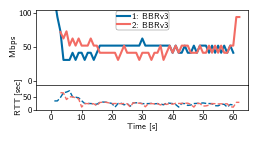

In [15]:
suffix = "_5"
plus_seconds = "+3"

flow1_fn = f"../data/fairness_data/flow1{plus_seconds}_10_no{suffix}.json"
with open(flow1_fn, "r") as flow1_fp:
    data1 = json.load(flow1_fp)

flow2_fn = f"../data/fairness_data/flow2{plus_seconds}_10_no{suffix}.json"
with open(flow2_fn, "r") as flow2_fp:
    data2 = json.load(flow2_fp)

fig, axs = plt.subplots(2,1,sharex=True,figsize=FIG_SIZE, gridspec_kw={
        'hspace': 0,
        'height_ratios': [3, 1]
    })

ax = axs[0]
ax2 = axs[1]

for it, data in enumerate([data1, data2]):
    diff_starts= data["start"]["timestamp"]["timesecs"] - data1["start"]["timestamp"]["timesecs"]
    intervals = data["intervals"]
    mbps_timeline = [int(i["streams"][0]["bits_per_second"])/1000000.0 for i in intervals]
    rtt_timeline = [int(i["streams"][0]["rtt"])/1000.0 for i in intervals]
    ts = [float(i["streams"][0]["end"])+diff_starts for i in intervals]
    overall_mean_iperf = data["end"]["sum_received"]["bits_per_second"]
    median_timeline = np.median(mbps_timeline)
    ax.plot(ts, mbps_timeline, label = f"{it+1}:~BBRv3", color=plotconfig.COLORS[it])
    ax2.plot(ts, rtt_timeline, color=plotconfig.COLORS[it], linestyle="--", linewidth=1)


ax.set_ylim(-5, 105)
ax.set_xlim(-5,65)
ax2.set_ylim(0,99)
ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax2.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax.set_ylabel("Mbps", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_ylabel("RTT [sec]", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_xlabel("Time [s]", fontsize=plotconfig.FONT_SIZE-3)
fig.subplots_adjust(
    hspace=0,
    bottom=0.15
)
ax.legend(loc="upper center", framealpha=0.7, fontsize=plotconfig.FONT_SIZE-3, title_fontsize=plotconfig.FONT_SIZE-3)
fig.savefig(f"figures/figure_18_a.pdf", format="pdf")

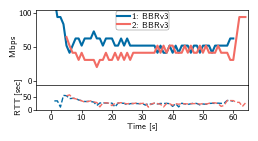

In [16]:
suffix = "_8"
plus_seconds = "+3"

flow1_fn = f"../data/fairness_data/flow1{plus_seconds}_10_no{suffix}.json"
with open(flow1_fn, "r") as flow1_fp:
    data1 = json.load(flow1_fp)

flow2_fn = f"../data/fairness_data/flow2{plus_seconds}_10_no{suffix}.json"
with open(flow2_fn, "r") as flow2_fp:
    data2 = json.load(flow2_fp)

fig, axs = plt.subplots(2,1,sharex=True,figsize=FIG_SIZE, gridspec_kw={
        'hspace': 0,
        'height_ratios': [3, 1]
    })

ax = axs[0]
ax2 = axs[1]

for it, data in enumerate([data1, data2]):
    diff_starts= data["start"]["timestamp"]["timesecs"] - data1["start"]["timestamp"]["timesecs"]
    intervals = data["intervals"]
    mbps_timeline = [int(i["streams"][0]["bits_per_second"])/1000000.0 for i in intervals]
    rtt_timeline = [int(i["streams"][0]["rtt"])/1000.0 for i in intervals]
    ts = [float(i["streams"][0]["end"])+diff_starts for i in intervals]
    overall_mean_iperf = data["end"]["sum_received"]["bits_per_second"]
    median_timeline = np.median(mbps_timeline)
    ax.plot(ts, mbps_timeline, label = f"{it+1}:~BBRv3", color=plotconfig.COLORS[it])
    ax2.plot(ts, rtt_timeline, color=plotconfig.COLORS[it], linestyle="--", linewidth=1)


ax.set_ylim(-5, 105)
ax.set_xlim(-5,65)
ax2.set_ylim(0,99)
ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax2.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax.set_ylabel("Mbps", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_ylabel("RTT [sec]", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_xlabel("Time [s]", fontsize=plotconfig.FONT_SIZE-3)
fig.subplots_adjust(
    hspace=0,
    bottom=0.15
)
ax.legend(loc="upper center", framealpha=0.7, fontsize=plotconfig.FONT_SIZE-3, title_fontsize=plotconfig.FONT_SIZE-3)
fig.savefig(f"figures/figure_18_b.pdf", format="pdf")

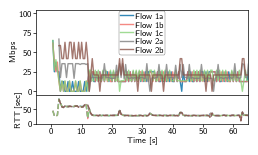

In [17]:
suffix = "_4"
plus_seconds = "+3"
flow1_scheduled = True

width = plotconfig.pt2inch(plotconfig.COLUMN_WIDTH)*(1/2)
height = width*(1/1.75)
FIG_SIZE = (width, height)

miffix1 = ""
miffix2 = ""


flow1_fn = f"../data/fairness_data/bbr1_5_flows_1{suffix}.json"
with open(flow1_fn, "r") as flow1_fp:
    data1 = json.load(flow1_fp)

flow2_fn = f"../data/fairness_data/bbr1_5_flows_2{suffix}.json"
with open(flow2_fn, "r") as flow2_fp:
    data2 = json.load(flow2_fp)

fig, axs = plt.subplots(2,1,sharex=True,figsize=FIG_SIZE, gridspec_kw={
        'hspace': 0,
        'height_ratios': [3, 1]
    })

ax = axs[0]
ax2 = axs[1]

for it, data in enumerate([data1, data2]):
    for iti in [0,1,2]:
        if it == 1 and iti ==2:
            continue
        diff_starts= data["start"]["timestamp"]["timesecs"] - data1["start"]["timestamp"]["timesecs"]
        intervals = data["intervals"]
        mbps_timeline = [int(i["streams"][iti]["bits_per_second"])/1000000.0 for i in intervals]
        rtt_timeline = [int(i["streams"][iti]["rtt"])/1000.0 for i in intervals]
        ts = [float(i["streams"][iti]["end"])+diff_starts for i in intervals]
        overall_mean_iperf = data["end"]["sum_received"]["bits_per_second"]
        median_timeline = np.median(mbps_timeline)
        ax.plot(ts, mbps_timeline, label = f"Flow {it+1}{ {0:"a",1:"b",2:"c"}[iti] }", color=plotconfig.COLORS[3*it+iti], alpha=0.8,linewidth=1)
        ax2.plot(ts, rtt_timeline, color=plotconfig.COLORS[3*it+iti], linestyle="--", linewidth=1, alpha=0.8)


ax.set_ylim(-5, 105)
ax.set_xlim(-5,65)
ax2.set_ylim(0,99)

ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax2.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax.set_ylabel("Mbps", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_ylabel("RTT [sec]", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_xlabel("Time [s]", fontsize=plotconfig.FONT_SIZE-3)
fig.subplots_adjust(
    hspace=0,
    bottom=0.15
)
ax.legend(loc="upper center", framealpha=0.7, fontsize=plotconfig.FONT_SIZE-3, title_fontsize=plotconfig.FONT_SIZE-3)
fig.savefig(f"figures/figure_19_a.pdf", format="pdf")

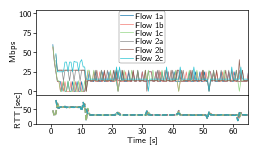

In [18]:
suffix = "_5"
flow1_scheduled = True

width = plotconfig.pt2inch(plotconfig.COLUMN_WIDTH)*(1/2)
height = width*(1/1.75)
FIG_SIZE = (width, height)

miffix1 = ""
miffix2 = ""


flow1_fn = f"../data/fairness_data/bbr1_6_flows_1{suffix}.json"
with open(flow1_fn, "r") as flow1_fp:
    data1 = json.load(flow1_fp)

flow2_fn = f"../data/fairness_data/bbr1_6_flows_2{suffix}.json"
with open(flow2_fn, "r") as flow2_fp:
    data2 = json.load(flow2_fp)

fig, axs = plt.subplots(2,1,sharex=True,figsize=FIG_SIZE, gridspec_kw={
        'hspace': 0,
        'height_ratios': [3, 1]
    })

ax = axs[0]
ax2 = axs[1]

for it, data in enumerate([data1, data2]):
    for iti in [0,1,2]:
        diff_starts= data["start"]["timestamp"]["timesecs"] - data1["start"]["timestamp"]["timesecs"]
        intervals = data["intervals"]
        mbps_timeline = [int(i["streams"][iti]["bits_per_second"])/1000000.0 for i in intervals]
        rtt_timeline = [int(i["streams"][iti]["rtt"])/1000.0 for i in intervals]
        ts = [float(i["streams"][iti]["end"])+diff_starts for i in intervals]
        overall_mean_iperf = data["end"]["sum_received"]["bits_per_second"]
        median_timeline = np.median(mbps_timeline)
        ax.plot(ts, mbps_timeline, label = f"Flow {it+1}{ {0:"a",1:"b",2:"c"}[iti] } {"" if 3*it+iti==0 else ""}", color=plotconfig.COLORS[3*it+iti], alpha=0.9,linewidth=0.5)
        ax2.plot(ts, rtt_timeline, color=plotconfig.COLORS[3*it+iti], linestyle="--", linewidth=1, alpha=0.8)


ax.set_ylim(-5, 105)
ax.set_xlim(-5,65)
ax2.set_ylim(0,99)
ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax2.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax.set_ylabel("Mbps", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_ylabel("RTT [sec]", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_xlabel("Time [s]", fontsize=plotconfig.FONT_SIZE-3)
fig.subplots_adjust(
    hspace=0,
    bottom=0.15
)
ax.legend(loc="upper center", framealpha=0.7, fontsize=plotconfig.FONT_SIZE-3, title_fontsize=plotconfig.FONT_SIZE-3)
fig.savefig(f"figures/figure_19_b.pdf", format="pdf")

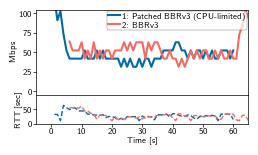

In [19]:
suffix = "_37"
plus_seconds = "+3"
flow1_scheduled = True

width = plotconfig.pt2inch(plotconfig.COLUMN_WIDTH)*(1/2)
height = width*(1/1.75)
FIG_SIZE = (width, height)

miffix1 = "_scheduled_50perc_10"
miffix2 = "_notscheduled_10_no_patch"


flow1_fn = f"../data/fairness_data/flow1{plus_seconds}{miffix1}{suffix}.json"
with open(flow1_fn, "r") as flow1_fp:
    data1 = json.load(flow1_fp)

flow2_fn = f"../data/fairness_data/flow2{plus_seconds}{miffix2}{suffix}.json"
with open(flow2_fn, "r") as flow2_fp:
    data2 = json.load(flow2_fp)

fig, axs = plt.subplots(2,1,sharex=True,figsize=FIG_SIZE, gridspec_kw={
        'hspace': 0,
        'height_ratios': [3, 1]
    })

ax = axs[0]
ax2 = axs[1]

for it, data in enumerate([data1, data2]):
    diff_starts= data["start"]["timestamp"]["timesecs"] - data1["start"]["timestamp"]["timesecs"]
    intervals = data["intervals"]
    mbps_timeline = [int(i["streams"][0]["bits_per_second"])/1000000.0 for i in intervals]
    rtt_timeline = [int(i["streams"][0]["rtt"])/1000.0 for i in intervals]
    ts = [float(i["streams"][0]["end"])+diff_starts for i in intervals]
    overall_mean_iperf = data["end"]["sum_received"]["bits_per_second"]
    median_timeline = np.median(mbps_timeline)
    ax.plot(ts, mbps_timeline, label = f"{it+1}:~{"Patched BBRv3 (CPU-limited)" if flow1_scheduled == (it == 0) else "BBRv3"}", color=plotconfig.COLORS[it])
    ax2.plot(ts, rtt_timeline, color=plotconfig.COLORS[it], linestyle="--", linewidth=1)


ax.set_ylim(-5, 105)
ax.set_xlim(-5,65)
ax2.set_ylim(0,99)
ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax2.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax.set_ylabel("Mbps", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_ylabel("RTT [sec]", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_xlabel("Time [s]", fontsize=plotconfig.FONT_SIZE-3)
fig.subplots_adjust(
    hspace=0,
    bottom=0.15
)
ax.legend(loc="upper right", framealpha=0.7, fontsize=plotconfig.FONT_SIZE-3, title_fontsize=plotconfig.FONT_SIZE-3)
fig.savefig(f"figures/figure_20_a.pdf", format="pdf")

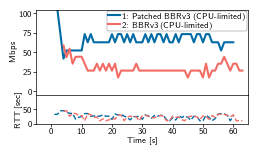

In [20]:
suffix = "_67"
plus_seconds = "+3"
flow1_scheduled = True

width = plotconfig.pt2inch(plotconfig.COLUMN_WIDTH)*(1/2)
height = width*(1/1.75)
FIG_SIZE = (width, height)

miffix1 = "_scheduled_50perc_10"
miffix2 = "_scheduled_50perc_10_no_patch"


flow1_fn = f"../data/fairness_data/flow1{plus_seconds}{miffix1}{suffix}.json"
with open(flow1_fn, "r") as flow1_fp:
    data1 = json.load(flow1_fp)

flow2_fn = f"../data/fairness_data/flow2{plus_seconds}{miffix2}{suffix}.json"
with open(flow2_fn, "r") as flow2_fp:
    data2 = json.load(flow2_fp)

fig, axs = plt.subplots(2,1,sharex=True,figsize=FIG_SIZE, gridspec_kw={
        'hspace': 0,
        'height_ratios': [3, 1]
    })

ax = axs[0]
ax2 = axs[1]

for it, data in enumerate([data1, data2]):
    diff_starts= data["start"]["timestamp"]["timesecs"] - data1["start"]["timestamp"]["timesecs"]
    intervals = data["intervals"]
    mbps_timeline = [int(i["streams"][0]["bits_per_second"])/1000000.0 for i in intervals]
    rtt_timeline = [int(i["streams"][0]["rtt"])/1000.0 for i in intervals]
    ts = [float(i["streams"][0]["end"])+diff_starts for i in intervals]
    overall_mean_iperf = data["end"]["sum_received"]["bits_per_second"]
    median_timeline = np.median(mbps_timeline)
    ax.plot(ts, mbps_timeline, label = f"{it+1}:~{"Patched BBRv3 (CPU-limited)" if flow1_scheduled == (it == 0) else "BBRv3 (CPU-limited)"}", color=plotconfig.COLORS[it])
    ax2.plot(ts, rtt_timeline, color=plotconfig.COLORS[it], linestyle="--", linewidth=1)


ax.set_ylim(-5, 105)
ax.set_xlim(-5,65)
ax2.set_ylim(0,99)
ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax2.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-3)
ax.set_ylabel("Mbps", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_ylabel("RTT [sec]", fontsize=plotconfig.FONT_SIZE-3)
ax2.set_xlabel("Time [s]", fontsize=plotconfig.FONT_SIZE-3)
fig.subplots_adjust(
    hspace=0,
    bottom=0.15
)
ax.legend(loc="upper right", framealpha=0.7, fontsize=plotconfig.FONT_SIZE-3, title_fontsize=plotconfig.FONT_SIZE-3)
fig.savefig(f"figures/figure_20_b.pdf", format="pdf")